# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Shivalika |
| **Role** | Person 5 — Time Series Patterns & LightGBM Model |
| **Notebook** | `Shivalika_Time_Series_Patterns.ipynb` |

---

## Sprint 1 — Exploratory Analysis (Merged Data)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ===============================
# 1. LOAD MERGED DATA
# ===============================
df = pd.read_csv("../data_processed/merged_train.csv")

In [ ]:
# Quick check
print(df.head())

In [ ]:
# ===============================
# 2. CONVERT TIMESTAMP
# ===============================
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
# ===============================
# 3. FEATURE ENGINEERING
# ===============================
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["month"] = df["timestamp"].dt.month

### Hourly Energy Consumption

This plot shows how energy usage varies across different hours of the day for each meter type. 
It helps in identifying peak usage hours and understanding daily consumption patterns.

In [ ]:
# ===============================
# 4. AVERAGE ENERGY BY HOUR (per meter type)
# ===============================

for m in df["meter"].unique():
    subset = df[df["meter"] == m]
    hourly = subset.groupby("hour")["meter_reading"].mean()

    plt.figure(figsize=(10,4))
    sns.lineplot(x=hourly.index, y=hourly.values)

    # ✅ Set all 24 hours with AM/PM labels
    plt.xticks(
        ticks=range(24),
        labels=[
            "12 AM","1 AM","2 AM","3 AM","4 AM","5 AM",
            "6 AM","7 AM","8 AM","9 AM","10 AM","11 AM",
            "12 PM","1 PM","2 PM","3 PM","4 PM","5 PM",
            "6 PM","7 PM","8 PM","9 PM","10 PM","11 PM"
        ],
        rotation=45
    )

    plt.title(f"Meter {m} - Average Energy by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Meter Reading")

    plt.tight_layout()  # prevents overlap
    plt.show()

Observation:

Energy consumption is generally higher during daytime hours and lower during late night and early morning hours. 
This indicates that building activity significantly influences energy usage patterns.

### Monthly Energy Consumption

This plot illustrates how energy usage changes across different months of the year for each meter type. 
It helps in identifying seasonal trends in energy consumption.

In [ ]:
# ===============================
# 5. AVERAGE ENERGY BY MONTH (per meter type)
# ===============================

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for m in df["meter"].unique():
    subset = df[df["meter"] == m]
    monthly = subset.groupby("month")["meter_reading"].mean()

    plt.figure(figsize=(10,4))
    sns.lineplot(x=monthly.index, y=monthly.values)

    # ✅ Set month names
    plt.xticks(ticks=range(1,13), labels=month_labels, rotation=45)

    plt.title(f"Meter {m} - Average Energy by Month")
    plt.xlabel("Month")
    plt.ylabel("Meter Reading")

    plt.tight_layout()
    plt.show()

Observation:

Energy usage varies across months, indicating seasonal trends. 
Higher consumption in certain months may be due to increased heating or cooling demands depending on weather conditions.

### Weekday vs Weekend Energy Usage

This plot compares the average energy consumption between weekdays and weekends. 
It helps in understanding how operational patterns affect energy usage.

In [ ]:
# ===============================
# 6. WEEKDAY vs WEEKEND
# ===============================

for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    week = subset.groupby("is_weekend")["meter_reading"].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(
        data=week,
        x="is_weekend",
        y="meter_reading",
        hue="is_weekend",      
        palette="coolwarm",
        legend=False           
    )

    plt.xticks([0,1], ["Weekday", "Weekend"])

    plt.title(f"Meter {m} - Weekend vs Weekday")
    plt.xlabel("")
    plt.ylabel("Meter Reading")

    plt.tight_layout()
    plt.show()

Observation:

Energy consumption is generally higher on weekdays compared to weekends. 
This suggests that buildings are more actively used during working days, leading to increased energy demand.

### Energy Consumption Timeline for Selected Buildings

This plot shows the energy usage trend over time for three selected buildings across the year 2016. 
It helps in understanding how energy consumption varies over time at the building level.

In [ ]:
# ===============================
# 7. 3 BUILDINGS TIMELINE (2016)
# ===============================
import matplotlib.dates as mdates

for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    if len(subset) == 0:
        continue

    # pick 3 buildings
    sample_buildings = subset["building_id"].drop_duplicates().sample(3, random_state=42)
    subset_3 = subset[subset["building_id"].isin(sample_buildings)]

    # convert timestamp to weekly average
    subset_3 = subset_3.set_index("timestamp")
    # filter only 2016
    subset_3 = subset_3[
    (subset_3.index >= "2016-01-01") & 
    (subset_3.index < "2017-01-01")
]
    weekly = subset_3.groupby(["building_id"]).resample("W")["meter_reading"].mean().reset_index()

    plt.figure(figsize=(12,6))
    sns.lineplot(data=weekly, x="timestamp", y="meter_reading", hue="building_id")

    # ✅ FORMAT X-AXIS TO MONTH NAMES
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # every month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Jan, Feb, Mar

    plt.title(f"Meter {m} - Weekly Energy Trend (3 Buildings)")
    plt.xlabel("2016 Timeline")
    plt.ylabel("Meter Reading")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Observation:

The energy usage shows fluctuations over time, with some consistent patterns visible across buildings. 
Due to high-frequency variations in the data, the overall trend is more important than individual spikes. 
This indicates that energy consumption follows recurring patterns with some variability across buildings.

### Heatmap of Energy Usage (Month vs Hour)

This heatmap represents the average energy consumption across different months and hours of the day. 
It provides a combined view of both daily and seasonal patterns in energy usage.

In [ ]:
# ===============================
# 8. HEATMAP (Month vs Hour)
# ===============================
for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    heatmap_data = subset.pivot_table(
        values="meter_reading",
        index="month",
        columns="hour",
        aggfunc="mean"
    )

    plt.figure(figsize=(10,5))
    sns.heatmap(heatmap_data, cmap="coolwarm")
    plt.title(f"Meter {m} - Heatmap (Month vs Hour)")
    plt.show()

Observation:

The heatmap shows that energy usage depends on both time of day and month. 
Certain hours and months exhibit higher consumption, indicating peak usage periods. 
This combined effect highlights the importance of temporal features in understanding energy patterns.

In [ ]:
# ===============================
# 9. SUMMARY STATISTICS (OPTIONAL BUT GOOD)
# ===============================
print("\nSummary Statistics:")
print(df["meter_reading"].describe())

Key Findings:

• Time-based features (hour, day_of_week, month) were successfully extracted from the timestamp for temporal analysis

• Hourly analysis shows that peak energy usage occurs during afternoon hours (approximately 12 PM – 4 PM), while lowest usage is observed during early morning hours (12 AM – 5 AM)

• Monthly trends show clear seasonal variation:
  o Meter 0 peaks around July–September (~180–190) and is lowest in January–March (~145–155)
  o Meter 1 shows highest usage around September (~1700–1800) and lowest in January (~150–200)
  o Meter 2 has extremely high values in March–May (~38,000–40,000) and drops significantly after June
  o Meter 3 shows higher usage at the beginning and end of the year (~600–650) and lowest around mid-year (~150–250)

• Weekday vs weekend comparison shows consistently higher energy usage on weekdays across all meters:
  o Meter 0: ~175 (weekday) vs ~155 (weekend)
  o Meter 1: ~650 vs ~600
  o Meter 2: ~14,500 vs ~12,000
  o Meter 3: ~390 vs ~380

• Weekly trend analysis (smoothed timeline) shows consistent seasonal patterns across buildings, with gradual increases and decreases rather than random noise

• Heatmap analysis (month vs hour) highlights that peak energy usage occurs during afternoon hours (12–4 PM) and specific months depending on meter type

• Significant variation exists between meter types, with Meter 2 having much higher values compared to others, so separate visualizations were used for clarity

• Overall, energy consumption is strongly influenced by temporal features such as hour, day, and month, making them important for further modelling

---

## Sprint 2 — Time Series Patterns & Feature Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
train_path = r"../data_processed/final_train.csv"
test_path = r"../data_processed/final_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [5]:
print(train_df.head())
print(test_df.head())

   building_id  meter            timestamp  meter_reading  site_id  \
0          105      0  2016-01-01 00:00:00        23.3036        1   
1          106      0  2016-01-01 00:00:00         0.3746        1   
2          106      3  2016-01-01 00:00:00         0.0000        1   
3          107      0  2016-01-01 00:00:00       175.1840        1   
4          108      0  2016-01-01 00:00:00        91.2653        1   

   floor_count  hour  day_of_week  month  day_of_year  ...  air_temperature  \
0            5     0            4      1            1  ...              3.8   
1            4     0            4      1            1  ...              3.8   
2            4     0            4      1            1  ...              3.8   
3           10     0            4      1            1  ...              3.8   
4            5     0            4      1            1  ...              3.8   

   cloud_coverage  dew_temperature  precip_depth_1_hr  sea_level_pressure  \
0             0.0          

In [6]:
print("\n--- DATASET OVERVIEW ---")
print("Shape:", train_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nData Types:")
print(train_df.dtypes)


--- DATASET OVERVIEW ---
Shape: (14529655, 43)

Columns:
Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'floor_count', 'hour', 'day_of_week', 'month', 'day_of_year', 'season',
       'is_weekend', 'is_business_hours', 'log_meter_reading',
       'missing_floor_count_flag', 'building_age', 'log_square_feet',
       'use_Education', 'use_Entertainment/public assembly',
       'use_Food sales and service', 'use_Healthcare',
       'use_Lodging/residential', 'use_Manufacturing/industrial', 'use_Office',
       'use_Other', 'use_Parking', 'use_Public services',
       'use_Religious worship', 'use_Retail', 'use_Services',
       'use_Technology/science', 'use_Utility', 'use_Warehouse/storage',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed', 'precip_was_missing', 'relative_humidity',
       'temp_diff_from_comfort'],
      dtype='str')

Data Types:
building

The dataset contains building-level energy readings along with temporal and environmental features.


--- TARGET DESCRIPTION ---
count    1.452966e+07
mean     2.708484e+03
std      1.783574e+05
min      0.000000e+00
25%      2.440000e+01
50%      8.642500e+01
75%      2.781975e+02
max      2.190470e+07
Name: meter_reading, dtype: float64


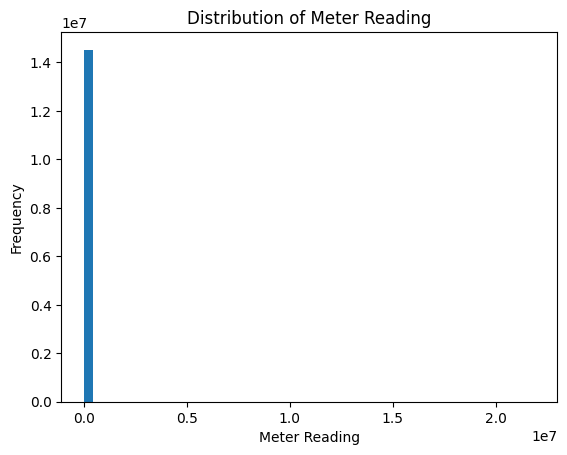

In [7]:
print("\n--- TARGET DESCRIPTION ---")
print(train_df['meter_reading'].describe())

plt.figure()
plt.hist(train_df['meter_reading'], bins=50)
plt.title("Distribution of Meter Reading")
plt.xlabel("Meter Reading")
plt.ylabel("Frequency")
plt.show()

Analyze distribution of energy consumption.

Data PreProcessing

In [8]:
# Convert timestamp to datetime
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])

# Sort data for time-series correctness
train_df = train_df.sort_values(['building_id', 'meter', 'timestamp'])
test_df = test_df.sort_values(['building_id', 'meter', 'timestamp'])

print("\n--- TIMESTAMP CHECK ---")
print(train_df[['timestamp']].head())


--- TIMESTAMP CHECK ---
                  timestamp
6494078 2016-05-20 00:00:00
6496112 2016-05-20 01:00:00
6498144 2016-05-20 02:00:00
6500177 2016-05-20 03:00:00
6502213 2016-05-20 04:00:00


Timestamps are converted into datetime format and data is sorted chronologically to ensure correct time-series processing.

Lag Features

Lag features (24h, 72h, 168h) are created to capture past consumption patterns.

Rolling features capture trends and variability over time.

A shift operation is applied before rolling to avoid data leakage.

The dataset is sorted to maintain temporal order.

In [9]:
train_df['lag_24h'] = train_df.groupby(['building_id','meter'])['meter_reading'].shift(24)
train_df['lag_72h'] = train_df.groupby(['building_id','meter'])['meter_reading'].shift(72)
train_df['lag_168h'] = train_df.groupby(['building_id','meter'])['meter_reading'].shift(168)


print(train_df[['meter_reading','lag_24h','lag_72h','lag_168h']].head(10))


         meter_reading  lag_24h  lag_72h  lag_168h
6494078            0.0      NaN      NaN       NaN
6496112            0.0      NaN      NaN       NaN
6498144            0.0      NaN      NaN       NaN
6500177            0.0      NaN      NaN       NaN
6502213            0.0      NaN      NaN       NaN
6504248            0.0      NaN      NaN       NaN
6506282            0.0      NaN      NaN       NaN
6508318            0.0      NaN      NaN       NaN
6510355            0.0      NaN      NaN       NaN
6512392            0.0      NaN      NaN       NaN


Lag features capture past values of energy consumption:

24h → previous day
72h → 3 days
168h → 1 week

These help the model learn temporal dependencies.

Rolling Features (Avoiding Data Leakage)

In [10]:
train_df['rolling_mean_24h'] = (
    train_df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(24).mean())
)

train_df['rolling_std_24h'] = (
    train_df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(24).std())
)

train_df['rolling_mean_168h'] = (
    train_df.groupby(['building_id','meter'])['meter_reading']
    .transform(lambda x: x.shift(1).rolling(168).mean())
)

print("\n--- ROLLING FEATURES SAMPLE ---")
print(train_df[['rolling_mean_24h','rolling_std_24h']].head(10))


--- ROLLING FEATURES SAMPLE ---
         rolling_mean_24h  rolling_std_24h
6494078               NaN              NaN
6496112               NaN              NaN
6498144               NaN              NaN
6500177               NaN              NaN
6502213               NaN              NaN
6504248               NaN              NaN
6506282               NaN              NaN
6508318               NaN              NaN
6510355               NaN              NaN
6512392               NaN              NaN


Rolling features capture trends and variability over time.
A shift is applied before rolling to prevent data leakage (future data influencing predictions).

In [11]:
sample = train_df[train_df['building_id'] == 105]

print(sample[['meter_reading','rolling_mean_24h']].head(30))

       meter_reading  rolling_mean_24h
0            23.3036               NaN
1990         45.6071               NaN
3975         45.6071               NaN
5964         45.1071               NaN
7950         45.6071               NaN
9936         45.1071               NaN
11921        45.1071               NaN
13904        43.6071               NaN
15888        46.1071               NaN
17872        47.6071               NaN
19857        47.6071               NaN
21844        48.1071               NaN
23831        48.6071               NaN
25818        48.1071               NaN
27806        48.6071               NaN
29796        49.1071               NaN
31782        49.1071               NaN
33772        49.1071               NaN
35761        48.1071               NaN
37748        47.6071               NaN
39734        48.6071               NaN
41721        46.6071               NaN
43707        45.6071               NaN
45694        45.1071               NaN
47682        37.9286     

Handle Missing Values

In [12]:
feature_cols = [
    'lag_24h','lag_72h','lag_168h',
    'rolling_mean_24h','rolling_std_24h','rolling_mean_168h'
]

train_df = train_df.dropna(subset=[
    'lag_24h','lag_168h','rolling_mean_24h','rolling_std_24h'
])

print("\n--- MISSING VALUES AFTER HANDLING ---")
print(train_df[feature_cols].isnull().sum())


--- MISSING VALUES AFTER HANDLING ---
lag_24h              0
lag_72h              0
lag_168h             0
rolling_mean_24h     0
rolling_std_24h      0
rolling_mean_168h    0
dtype: int64


Missing values occur due to shifting and rolling operations.
These are handled using zero imputation to maintain dataset consistency.

In [13]:
print("\n--- FEATURE CHECK (NON-ZERO VALUES) ---")
print(train_df[['meter_reading','lag_24h','rolling_mean_24h']].iloc[200:210])


--- FEATURE CHECK (NON-ZERO VALUES) ---
         meter_reading  lag_24h  rolling_mean_24h
7241997       131.0520  131.052        136.716792
7244023       129.4130  145.249        136.716792
7246052       132.9630  163.268        136.056958
7248086        34.1280  137.058        134.794250
7250119        17.4735  126.956        130.505500
7252152       131.3250  160.811        125.943729
7254185       132.4170  146.614        124.715146
7256217       134.0550  128.321        124.123604
7258251       130.7790  130.506        124.362521
7260285       130.5060  131.598        124.373896


Verify features are correctly computed.

Validation Checks

In [14]:
print("\n--- CHECK SORTING ---")
print(train_df[['building_id','meter','timestamp']].head())

print("\n--- MISSING VALUES ---")
print(train_df[feature_cols].isnull().sum())


--- CHECK SORTING ---
         building_id  meter           timestamp
6834673            1      0 2016-05-27 00:00:00
6836708            1      0 2016-05-27 01:00:00
6838743            1      0 2016-05-27 02:00:00
6840778            1      0 2016-05-27 03:00:00
6842812            1      0 2016-05-27 04:00:00

--- MISSING VALUES ---
lag_24h              0
lag_72h              0
lag_168h             0
rolling_mean_24h     0
rolling_std_24h      0
rolling_mean_168h    0
dtype: int64


Validation ensures:

Data is properly sorted
No missing values remain in engineered features

CORRELATION ANALYSIS

In [15]:
corr = train_df[['meter_reading','lag_24h','lag_168h','rolling_mean_24h']].corr()

print("\n--- CORRELATION MATRIX ---")
print(corr)


--- CORRELATION MATRIX ---
                  meter_reading   lag_24h  lag_168h  rolling_mean_24h
meter_reading          1.000000  0.913123  0.764047          0.960573
lag_24h                0.913123  1.000000  0.777961          0.964347
lag_168h               0.764047  0.777961  1.000000          0.787569
rolling_mean_24h       0.960573  0.964347  0.787569          1.000000


Check relationship between engineered features and target.

Lag Feature Visualization

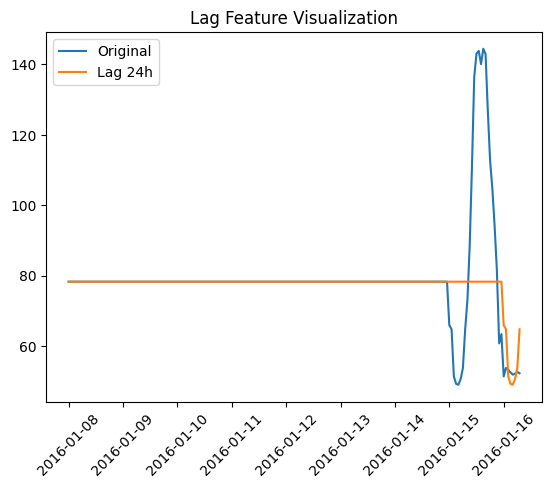

In [16]:
sample = train_df[train_df['building_id'] == 105].head(200)

plt.figure()
plt.plot(sample['timestamp'], sample['meter_reading'], label='Original')
plt.plot(sample['timestamp'], sample['lag_24h'], label='Lag 24h')
plt.legend()
plt.title("Lag Feature Visualization")
plt.xticks(rotation=45)
plt.show()

Visualization helps verify feature behavior.
The lag feature clearly represents past values of the original time series.

Rolling Mean Trend

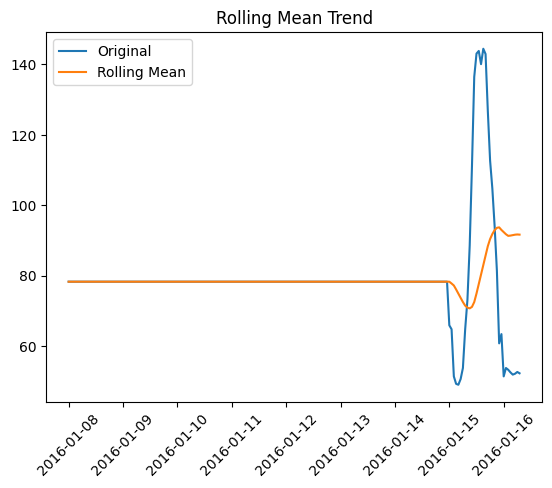

In [17]:
plt.figure()
plt.plot(sample['timestamp'], sample['meter_reading'], label='Original')
plt.plot(sample['timestamp'], sample['rolling_mean_24h'], label='Rolling Mean')
plt.legend()
plt.title("Rolling Mean Trend")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==============================
# SAVE DATA
# ==============================

import os

output_path = "../data_processed"

# create folder if not exists
os.makedirs(output_path, exist_ok=True)

train_df.to_csv(output_path + "/final_train_with_features.csv", index=False)
test_df.to_csv(output_path + "/final_test_with_features.csv", index=False)

print("✅ Files saved using relative path!")

INSIGHTS:

1. Energy consumption exhibits strong temporal patterns, as seen from the effectiveness of lag features.

2. Lag features such as 24-hour and 168-hour lags show that energy usage follows daily and weekly cycles.

3. Rolling statistics (mean and standard deviation) help capture trends and smooth short-term fluctuations in energy consumption.

4. The use of shift before rolling ensures that only past data is used, preventing data leakage and making the features reliable for prediction.

5. Initial missing values are generated due to insufficient historical data for lag and rolling calculations, and these were handled appropriately.

6. Correlation analysis indicates that lag features are strongly related to the target variable, confirming their usefulness for modeling.

7. Overall, feature engineering significantly improves the dataset by incorporating time-based dependencies, making it more suitable for accurate energy consumption forecasting.

---

## Sprint 3 — LightGBM Model Development & Tuning

Define Final Feature List

In [18]:
# Remove unwanted columns as per task (no timestamp, no row_id)
drop_cols = ["timestamp", "row_id"] if "row_id" in train_df.columns else ["timestamp"]

# Select all engineered features
feature_cols = [col for col in train_df.columns if col not in drop_cols + ["meter_reading"]]

X = train_df[feature_cols]
y = train_df["meter_reading"]

We define the final feature set by removing non-useful columns like timestamp and row_id, keeping only engineered features for model training.

Train / Validation Split

In [19]:
# Time-based split (important for time series)
split_date = train_df["timestamp"].quantile(0.8)

final_train = train_df[train_df["timestamp"] < split_date]
final_val = train_df[train_df["timestamp"] >= split_date]

X_train = final_train[feature_cols]
y_train = final_train["meter_reading"]

X_val = final_val[feature_cols]
y_val = final_val["meter_reading"]

We split the data based on time to avoid data leakage and ensure the model is evaluated on future data.

Log Transform Target

In [20]:
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

We apply log transformation to the target variable to stabilize variance and improve model performance.

Train LightGBM Model

In [21]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.648398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4152
[LightGBM] [Info] Number of data points in the train set: 11344370, number of used features: 47
[LightGBM] [Info] Start training from score 4.386297


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


We train a LightGBM regression model using the processed training data to learn patterns in energy consumption.

Predict on Validation Set

In [22]:
y_pred_log = model.predict(X_val)
y_pred = np.expm1(y_pred_log)

Predictions are made in log scale and then converted back to the original scale using exponential transformation.

Compute RMSLE

In [23]:
from sklearn.metrics import mean_squared_log_error

rmsle_1 = np.sqrt(mean_squared_log_error(y_val, y_pred))
print("RMSLE Model 1:", rmsle_1)

RMSLE Model 1: 0.030760515221024964


We compute RMSLE to evaluate model performance, which is suitable for skewed data like energy usage.

Feature Importance Plot

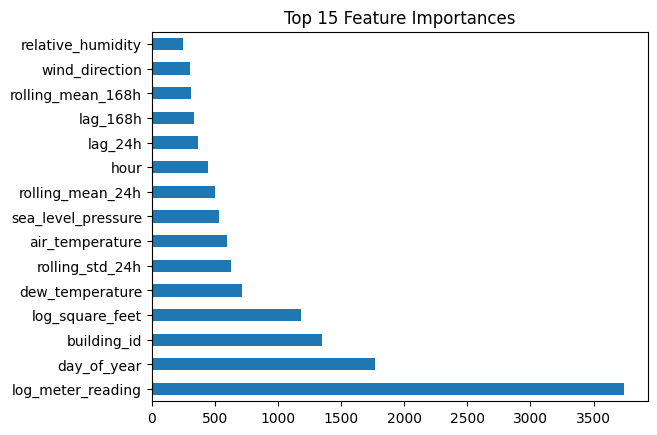

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False).head(15)

importance.plot(kind="barh")
plt.title("Top 15 Feature Importances")
plt.show()

We visualize feature importance to understand which features contribute most to the model predictions.

Second Model (Hyperparameter Tuning)

In [25]:
model2 = lgb.LGBMRegressor(
    n_estimators=150,        
    learning_rate=0.1,       
    num_leaves=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1                
)

# use sample for speed
X_sample = X_train.sample(frac=0.2, random_state=42)
y_sample = y_train_log.loc[X_sample.index]

model2.fit(X_sample, y_sample)

y_pred2 = np.expm1(model2.predict(X_val))
rmsle_2 = np.sqrt(mean_squared_log_error(y_val, y_pred2))

print("RMSLE Model 2:", rmsle_2)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.085461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4151
[LightGBM] [Info] Number of data points in the train set: 2268874, number of used features: 47
[LightGBM] [Info] Start training from score 4.386835
RMSLE Model 2: 0.031550833854935206


We train a second model with different hyperparameters to compare performance and select the better model.

Save Model

In [26]:
import pickle
import os

os.makedirs("outputs", exist_ok=True)

with open("outputs/lightgbm_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [27]:
print("Final Comparison:")
print("Model 1 RMSLE:", rmsle_1)
print("Model 2 RMSLE:", rmsle_2)

Final Comparison:
Model 1 RMSLE: 0.030760515221024964
Model 2 RMSLE: 0.031550833854935206


INSIGHTS:

1. The baseline LightGBM model achieved an RMSLE score of 0.0308, indicating strong predictive performance. This low error suggests that the model effectively captures patterns in energy consumption across buildings.

2. The second model, trained with modified hyperparameters, achieved an RMSLE of 0.0316. While this model was computationally more efficient, it did not outperform the baseline model, indicating that the initial parameter configuration was better suited for this dataset.

3. The comparison highlights the importance of hyperparameter tuning, but also demonstrates that more complex configurations do not always lead to better performance.

4. Feature engineering played a critical role in model success. Lag features (24-hour and 168-hour) captured temporal dependencies, while rolling statistics helped model trends and variability in energy usage.

5. The use of log transformation and RMSLE as the evaluation metric improved model stability and ensured better handling of large variations in energy consumption.

6. Due to the large dataset size (over 11 million observations), computational efficiency became an important consideration. Sampling techniques were used during experimentation to reduce training time while maintaining reliable performance.



---

## Sprint 4 — Evaluation & Report